# Clustering 

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pickle
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from functions import *
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
with open('processed_data.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

X_scaled = loaded_data['X_scaled']
habit_features = loaded_data['feature_names']
df = loaded_data['original_df']

print(f"Ready to cluster {X_scaled.shape[0]} rows with {len(habit_features)} features.")

Ready to cluster 2000 rows with 8 features.


## K-means

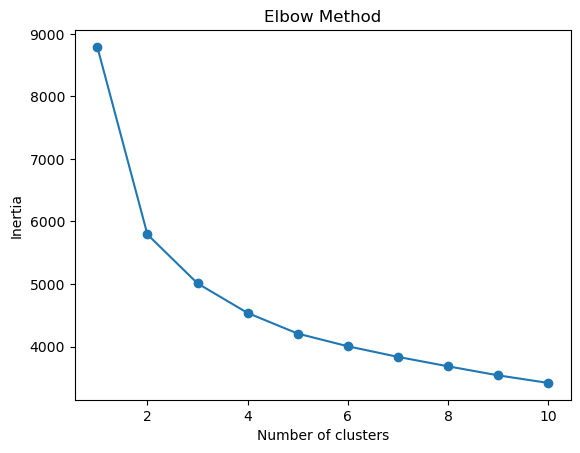

In [3]:
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

In [4]:
print("Inertia values:", [round(x, 2) for x in inertia])

Inertia values: [8790.4, 5792.09, 5010.4, 4537.46, 4207.91, 4005.31, 3835.69, 3684.83, 3540.35, 3419.29]


By the elbow curve, the suggested number of clusters could be 3 (or 4).

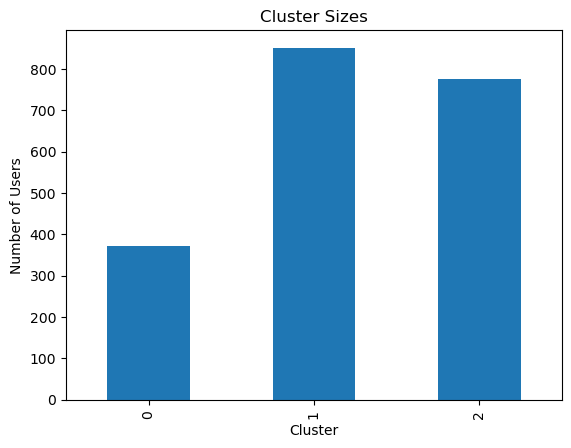

In [7]:
kmeans_3 = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans_3.fit_predict(X_scaled)

# Add cluster labels to the original dataframe
df['cluster_kmeans'] = clusters

df.groupby('cluster_kmeans').size().plot(kind='bar')
plt.title('Cluster Sizes')
plt.xlabel('Cluster')
plt.ylabel('Number of Users')
plt.show()

Cluster centroids (mean values for each feature):
                work_hours  meetings_count  breaks_taken  after_hours_work  \
cluster_kmeans                                                               
0                11.574531        7.533512      3.672922          0.372654   
1                 7.766686        2.676851      6.505288          0.091657   
2                 9.001598        3.052835      4.157216          0.123711   

                app_switches  sleep_hours  task_completion  isolation_index  
cluster_kmeans                                                               
0                  86.305630     5.539625        66.984638         6.442359  
1                  44.820212     7.280270        87.590376         4.713278  
2                  53.759021     7.123724        78.165799         4.300258  


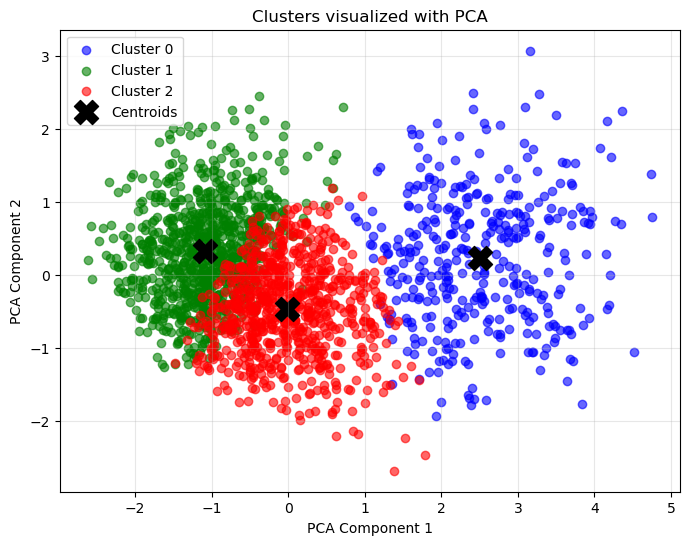

In [10]:
cluster_summary = df.groupby('cluster_kmeans')[habit_features].mean()
print("Cluster centroids (mean values for each feature):")
print(cluster_summary)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Transform centroids to PCA space
centroids_pca = pca.transform(kmeans_3.cluster_centers_)

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for cluster in range(3):
    plt.scatter(X_pca[clusters == cluster, 0], X_pca[clusters == cluster, 1], 
                label=f'Cluster {cluster}', alpha=0.6, color=colors[cluster])
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title('Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Hierarchical clustering

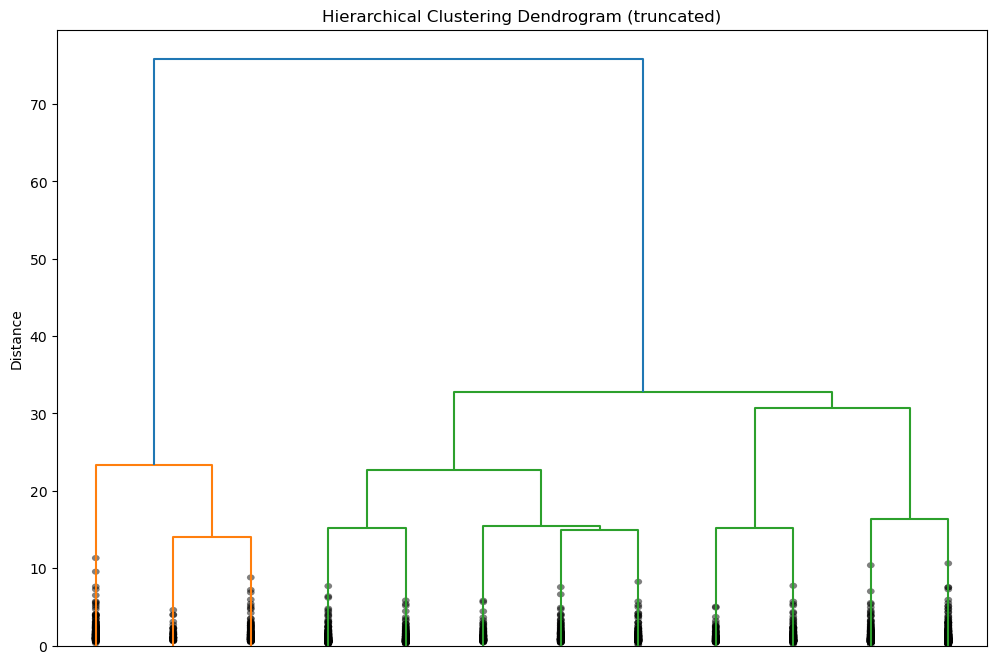

In [ ]:

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 8))
dendrogram(Z, truncate_mode='lastp', p=12, leaf_rotation=45., leaf_font_size=10., show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (truncated)')
plt.ylabel('Distance') 
plt.show()

The dendogram suggests 3 clusters.

K-means cluster sizes:
cluster_kmeans
0    373
1    851
2    776
dtype: int64

Hierarchical cluster sizes:
cluster_hier
0    397
1    753
2    850
dtype: int64

Adjusted Rand Index between K-means and Hierarchical: 0.487


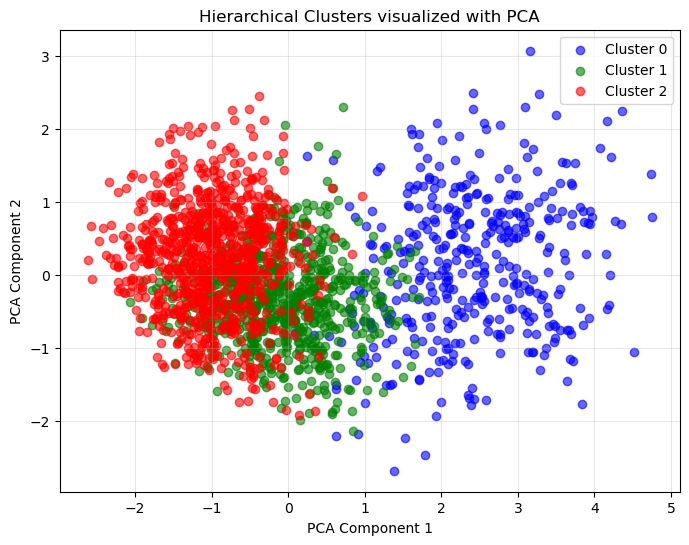

In [ ]:
clusters_hier = fcluster(Z, 3, criterion='maxclust')

df['cluster_hier'] = clusters_hier - 1  

print("K-means cluster sizes:")
print(df.groupby('cluster_kmeans').size())
print("\nHierarchical cluster sizes:")
print(df.groupby('cluster_hier').size())

from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['cluster_kmeans'], df['cluster_hier'])
print(f"\nAdjusted Rand Index between K-means and Hierarchical: {ari:.3f}")

plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
for cluster in range(3):
    mask = clusters_hier == (cluster + 1)  
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                label=f'Cluster {cluster}', alpha=0.6, color=colors[cluster])
plt.title('Hierarchical Clusters visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## SOM

In [1]:
!pip install minisom

  Using cached minisom-2.3.6.tar.gz (13 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for minisom: filename=MiniSom-2.3.6-py3-none-any.whl size=13095 sha256=36ee5494937227986a3d680d06c425f214bfa8514ffc36d7c7179ccda1b3607b
  Stored in directory: c:\users\lucas\appdata\local\pip\cache\wheels\dc\11\f9\32be492f07fa741d7dcff82007abc966a324da6ab9ceb198e3
Successfully built minisom


  DEPRECATION: Building 'minisom' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'minisom'. Discussion can be found at https://github.com/pypa/pip/issues/6334


 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.9367385544920622
SOM cluster sizes:
cluster_som
0    719
1    617
2    664
dtype: int64


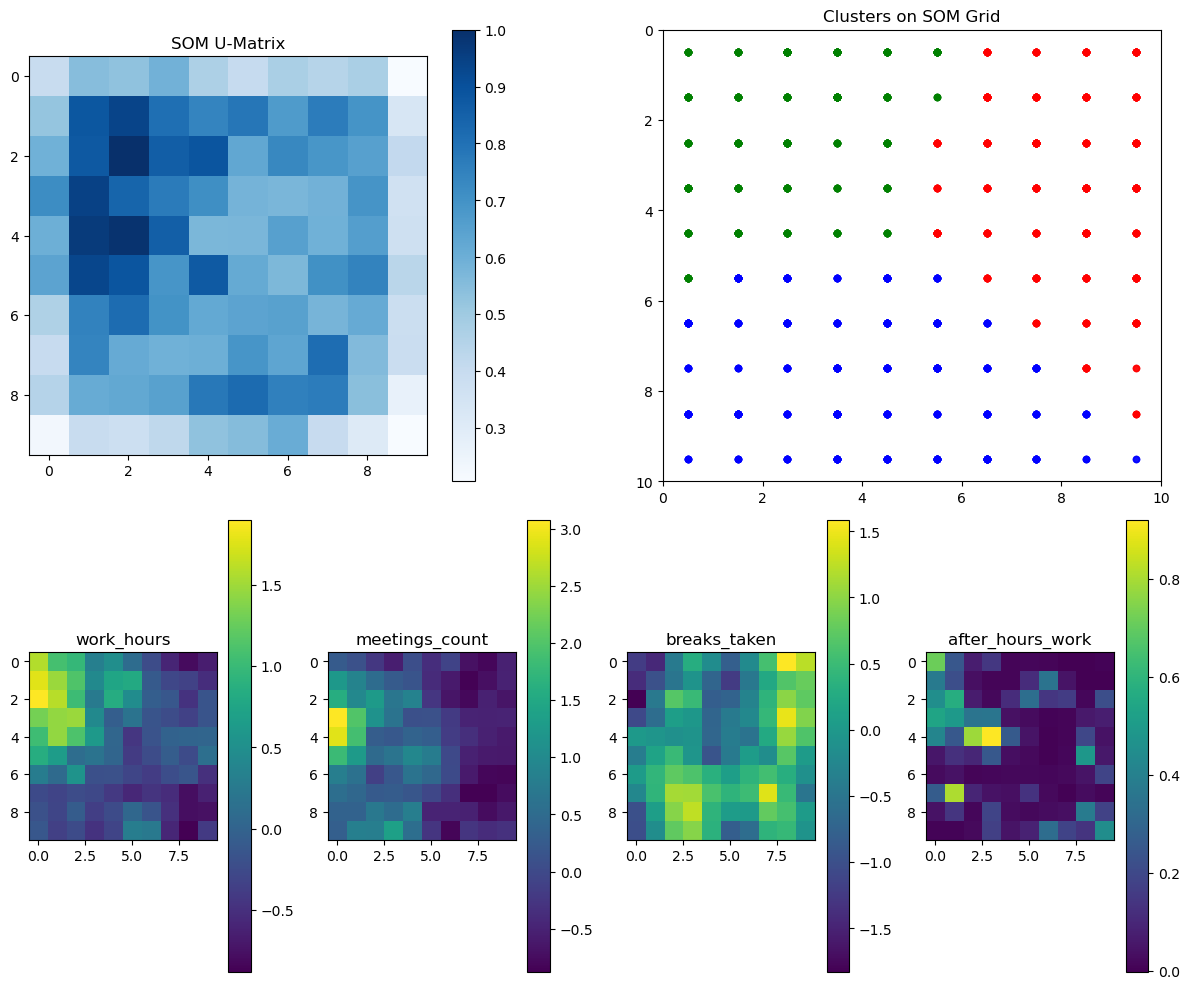

In [5]:
from minisom import MiniSom
import numpy as np

# Initialize SOM with a 10x10 grid
som_size = 10
som = MiniSom(som_size, som_size, X_scaled.shape[1], sigma=1.0, learning_rate=0.5, random_seed=42)

# Train the SOM
som.train(X_scaled, 1000, verbose=True)

# Get the winning neurons for each data point
winner_coordinates = np.array([som.winner(x) for x in X_scaled])

# Create a mapping from SOM coordinates to cluster labels
from sklearn.cluster import KMeans
som_clusters = KMeans(n_clusters=3, random_state=42).fit_predict(winner_coordinates)

# Add SOM clusters to dataframe
df['cluster_som'] = som_clusters

print("SOM cluster sizes:")
print(df.groupby('cluster_som').size())

# Visualize SOM results
plt.figure(figsize=(12, 10))

# Plot 1: U-Matrix (distance between neurons)
plt.subplot(2, 2, 1)
plt.title('SOM U-Matrix')
u_matrix = som.distance_map()
plt.imshow(u_matrix, cmap='Blues')
plt.colorbar()

# Plot 2: Clusters on SOM grid
plt.subplot(2, 2, 2)
plt.title('Clusters on SOM Grid')
colors = ['blue', 'green', 'red']
for i, (x, y) in enumerate(winner_coordinates):
    plt.scatter(x + 0.5, y + 0.5, color=colors[som_clusters[i]], alpha=0.6, s=20)
plt.xlim(0, som_size)
plt.ylim(0, som_size)
plt.gca().invert_yaxis()

# Plot 3: Component planes (first 4 features)
feature_names = habit_features[:4]  # Show first 4 features
for i, feature in enumerate(feature_names):
    plt.subplot(2, 4, 5 + i)
    plt.title(f'{feature}')
    weights = som.get_weights()[:, :, i]
    plt.imshow(weights, cmap='viridis')
    plt.colorbar()

plt.tight_layout()
plt.show()

# DBScan

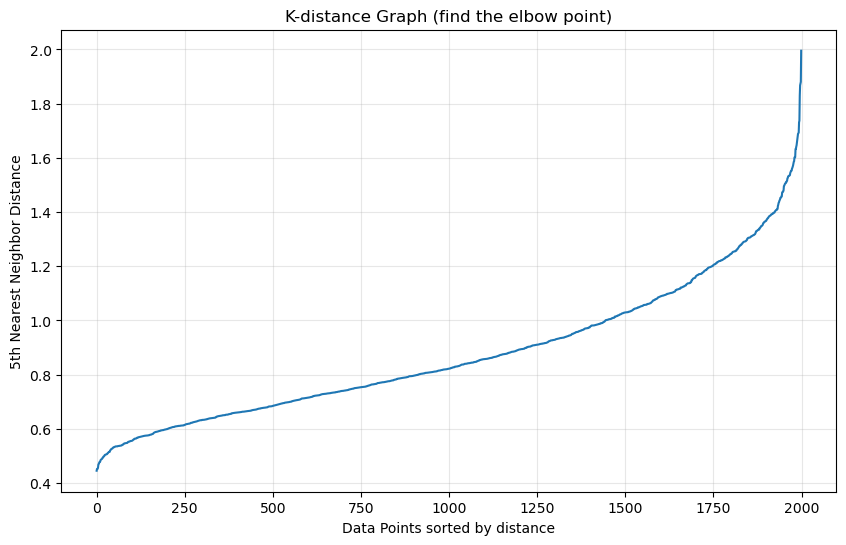

Distance percentiles:
  50th: 0.822
  60th: 0.893
  70th: 0.975
  75th: 1.029
  80th: 1.088
  90th: 1.246

Using 70th percentile eps value: 0.975

DBSCAN cluster counts (eps=0.975):
cluster_dbscan
-1     353
 0    1517
 1      49
 2      32
 3      25
 4       4
 5       5
 6       5
 7       5
 8       5
Name: count, dtype: int64
Noise points: 353
Number of clusters: 9


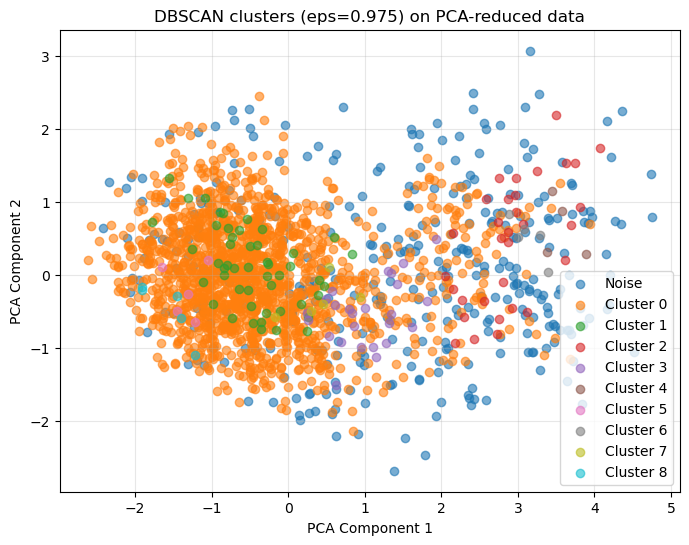

In [12]:
# Find optimal eps using k-distance graph
from sklearn.neighbors import NearestNeighbors

k = 5  # min_samples value
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, k-1], axis=0)

# Plot k-distance graph to find elbow
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.ylabel('5th Nearest Neighbor Distance')
plt.xlabel('Data Points sorted by distance')
plt.title('K-distance Graph (find the elbow point)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Distance percentiles:")
print(f"  50th: {np.percentile(distances, 50):.3f}")
print(f"  60th: {np.percentile(distances, 60):.3f}")
print(f"  70th: {np.percentile(distances, 70):.3f}")
print(f"  75th: {np.percentile(distances, 75):.3f}")
print(f"  80th: {np.percentile(distances, 80):.3f}")
print(f"  90th: {np.percentile(distances, 90):.3f}")

# Try lower percentile for more clusters (adjust this value to find sweet spot)
percentile_to_use = 70  # More granular than 90th
suggested_eps = np.percentile(distances, percentile_to_use)
print(f"\nUsing {percentile_to_use}th percentile eps value: {suggested_eps:.3f}")

# Now fit DBSCAN with better eps
X_scaled_df = pd.DataFrame(X_scaled, columns=habit_features)
dbscan_labels = DBSCAN(eps=suggested_eps, min_samples=5).fit_predict(X_scaled_df)

df['cluster_dbscan'] = dbscan_labels

print(f'\nDBSCAN cluster counts (eps={suggested_eps:.3f}):')
print(df['cluster_dbscan'].value_counts().sort_index())
print(f"Noise points: {(dbscan_labels == -1).sum()}")
print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")

# Visualize DBSCAN clustering with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(8, 6))
unique_labels = sorted(set(dbscan_labels))
colors = plt.cm.get_cmap('tab10', max(1, len(unique_labels)))
for idx, label in enumerate(unique_labels):
    mask = dbscan_labels == label
    label_name = 'Noise' if label == -1 else f'Cluster {label}'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=label_name, alpha=0.6,
                color=colors(idx))

plt.title(f'DBSCAN clusters (eps={suggested_eps:.3f}) on PCA-reduced data')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
